In [1]:
import dill
with open(f'results_paper/lindblad_control/a=0.1,T=1/dt=5.0/2000ps', 'rb') as f:
    opt_prot = dill.load(f)
results_lindblad_temp={}
results_lindblad_temp[(5.0)] = opt_prot

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


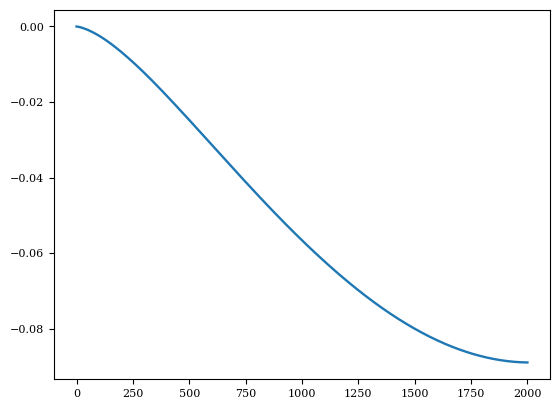

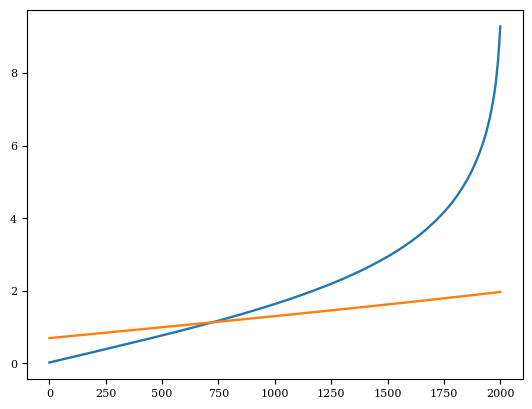

In [28]:
import matplotlib.pyplot as plt
import numpy as np
t_total=2000
for key in results_lindblad_temp:
    plt.plot(np.linspace(0,t_total,int(t_total/key)+1), results_lindblad_temp[key]['heats'], label=f"dt={key}")

plt.show()

for key in results_lindblad_temp:
    hx=results_lindblad_temp[key]['x_opt']
    delta=-2*hx/0.131
    delta_reversed=delta[::-1]
    plt.plot(np.linspace(0,t_total,int(t_total/key)), delta_reversed, label=f"dt={key}")

def min_dissip(A,B,t,tau_prot):
    return 2*np.log(np.sqrt(2)/np.tan(A+B*t/tau_prot))

t=np.linspace(0,t_total,int(t_total//5))
A=np.pi/4
EA=hx[-1]-hx[0]
B=-np.arcsin(np.tanh(EA/2))
plt.plot(t,min_dissip(A,B,t,t_total))

plt.show()

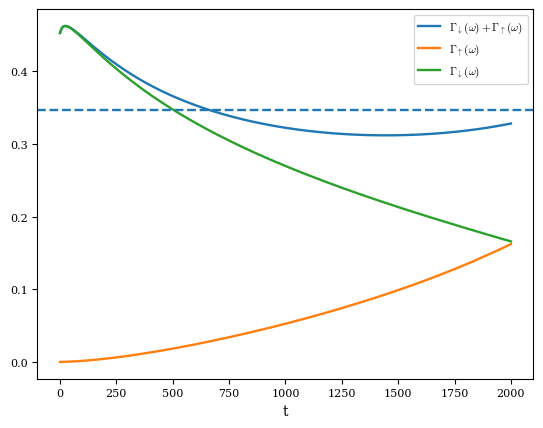

0.34666192960706643
-0.090336077824992


In [30]:
alpha=0.1
temp=0.131
omega_c=1
def J(w):
        return 2 * alpha * w * np.exp(-w / omega_c)
def n(w):
        return 1.0 / (np.exp(w / temp) - 1.0)

omega_t=np.abs(results_lindblad_temp[5]['x_opt']*2)

gamma_up= 2*np.pi*J(omega_t)* n(omega_t)
gamma_down= 2*np.pi*J(omega_t)* (n(omega_t)+1)

therm_rate= gamma_up+gamma_down

plt.plot(t,therm_rate, label=r"$\Gamma_{\downarrow}(\omega)+\Gamma_{\uparrow}(\omega)$")
plt.plot(t,gamma_up, label=r"$\Gamma_{\uparrow}(\omega)$")
plt.plot(t,gamma_down, label=r"$\Gamma_{\downarrow}(\omega)$")
plt.xlabel("t")
av_therm=np.trapz(therm_rate,t)/t_total
plt.axhline(av_therm,linestyle='dashed')
plt.legend()
plt.show()
print(av_therm)
print(0.131*(-np.log(2)+(np.pi**2)/(4*av_therm*t_total)))

In [31]:
def omega_t_discrete(hx):
    return -2*hx-1e-7

def make_rates(alpha, T):
    def J(w):
        return 2 * alpha * w * np.exp(-w / omega_c)

    def n(w):
        return 1.0 / (np.exp(w / T) - 1.0)

    def gammaA(hx):
        w = omega_t_discrete(hx)
        return 2 * np.pi * J(w) * n(w)

    def gammaE(hx):
        w = omega_t_discrete(hx)
        return 2 * np.pi * J(w) * (n(w) + 1)

    def DgammaA(hx):
        w = omega_t_discrete(hx)
        nw = n(w)
        Jw = J(w)
        dJ_dw = 2 * alpha * np.exp(-w / omega_c) * (1 - w / omega_c)
        dn_dw = -nw * (1 + nw) / T
        return 2 * np.pi * (dJ_dw * nw + Jw * dn_dw) * (-2.0)

    def DgammaE(hx):
        w = omega_t_discrete(hx)
        nw = n(w)
        Jw = J(w)
        dJ_dw = 2 * alpha * np.exp(-w / omega_c) * (1 - w / omega_c)
        dn_dw = -nw * (1 + nw) / T
        return 2 * np.pi * (dJ_dw * (nw + 1) + Jw * dn_dw) * (-2.0)

    return gammaA, gammaE, DgammaA, DgammaE

In [32]:
from scipy.linalg import expm, logm
import oqupy.operators as op

rho0=op.spin_dm("x+")
sx = np.array([[0, 1], [1, 0]]) / 2 
sz = np.array([[1, 0], [0, -1]]) / 2

rplus = -0.5 * (sz + 2 * sz @ sx) 
rminus = -0.5 * (sz - 2 * sz @ sx) 

def relative_entropy_from_optimal_control(
    x_opt, num_steps, alpha, T, dt
):

    gammaA, gammaE,_,_=make_rates(alpha, T)

    rho = rho0.copy()

    rel_entropy = []
    states = [rho]
    tau_list = []

    for k in range(num_steps):

        hx = x_opt[k]

        # ----- Hamiltonian -----
        H = 2 * hx * sx

        L = -1j * op.commutator(H)

        # ----- dissipator -----
        rates = [gammaE(hx), gammaA(hx)]
        L_ops = [rminus, rplus]

        for Lop, g in zip(L_ops, rates):
            Ld = Lop.conj().T
            L += g * op.left_right_super(Lop, Ld)
            L += -0.5 * g * op.acommutator(Ld @ Lop)

        

        # ----- exact timestep propagator -----
        E = expm(dt * L)

        rho_vec = E @ rho.reshape(-1)
        rho = rho_vec.reshape(2, 2)

        # numerical cleanup
        rho = 0.5 * (rho + rho.conj().T)
        rho /= np.trace(rho)

        states.append(rho)

        # ----- instantaneous Gibbs state -----
        beta = 1 / T
        tau = expm(-beta * H) # negative hamiltonian
        tau /= np.trace(tau)

        # ----- relative entropy -----
        D_rt = np.real(
            np.trace(rho @ (logm(rho) - logm(tau)))
        )

        rel_entropy.append(D_rt)
        tau_list.append(tau)

    tau_list = np.array(tau_list)
    rel_entropy = np.array(rel_entropy)
    d_rel_entropy_dt = np.gradient(rel_entropy, dt)

    return states, rel_entropy, d_rel_entropy_dt,tau_list

num_steps=int(2000/5)

states, D, Ddot, taus = relative_entropy_from_optimal_control(
    results_lindblad_temp[5.0]["x_opt"],
    num_steps,
    alpha,
    0.131,
    5
)

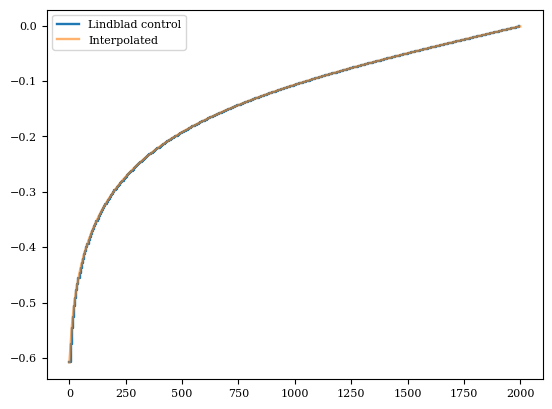

In [33]:
import oqupy,dill
from scipy.interpolate import interp1d

from oqupy.system import TimeDependentSystem

with open(f'results/processtensors/processtensor_dt=0.25_ps=-8.0_tcut=500', 'rb') as f:
    process_tensor=dill.load(f)

dt_L = 5             
dt_tempo = 0.25
dt=5
t_total=2000
hx = results_lindblad_temp[dt]["x_opt"]

t_L = np.arange(len(hx)) * dt_L

# TEMPO simulation times
t_T = np.arange(int(t_total/dt_tempo)+1) * dt_tempo

h_t = interp1d(
    t_L,
    hx,
    kind="cubic",     
    bounds_error=False,
    fill_value=(hx[0], hx[-1])
)
plt.step(t_L, hx, where="post", label="Lindblad control")
plt.plot(t_T, h_t(t_T), alpha=0.6, label="Interpolated")
plt.legend()
plt.show()

In [34]:


sys= TimeDependentSystem(lambda t : op.sigma("x")*h_t(t))

dynamics = oqupy.compute_dynamics(
    process_tensor=process_tensor, 
    system=sys,
    initial_state=rho0,
    start_time=0,
    num_steps=int(t_total/dt_tempo))

--> Compute dynamics:
100.0% 8000 of 8000 [########################################] 00:08:09
Elapsed time: 489.6s


In [35]:
# finer plot for inset
with open(f'results/processtensors/processtensor_dt=0.1_ps=-8.0_tcut=500', 'rb') as f:
    process_tensor_finer=dill.load(f)
dt_fine=0.1
dynamics_finer = oqupy.compute_dynamics(
    process_tensor=process_tensor_finer, 
    system=sys,
    initial_state=rho0,
    start_time=0,
    num_steps=int(10/dt_fine))


--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:05
Elapsed time: 5.4s


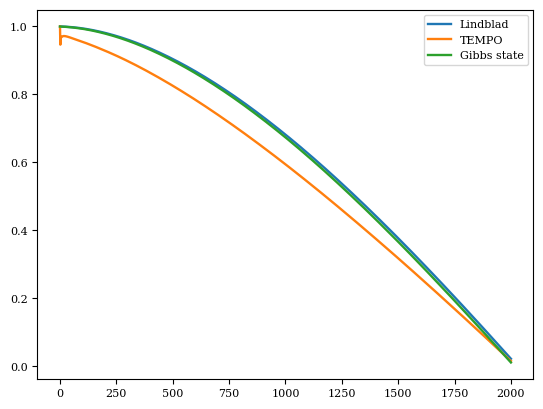

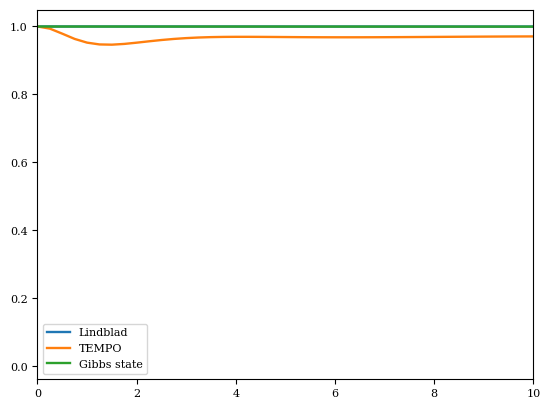

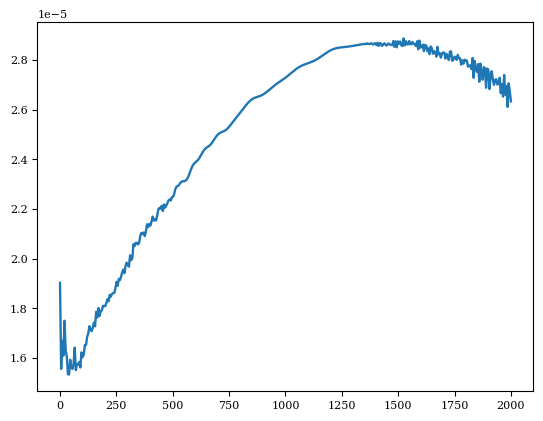

In [36]:
plt.plot(t,[np.trace(state @ op.sigma("x")) for state in states[:-1]],label="Lindblad")

plt.plot(t_T,[np.trace(state @ op.sigma("x")) for state in dynamics.states], label="TEMPO")
plt.plot(t,[np.trace(state@op.sigma(("x") )) for state in taus], linestyle='-', label="Gibbs state")
plt.legend()
plt.show()

plt.plot(t,[np.trace(state @ op.sigma("x")) for state in states[:-1]],label="Lindblad")

plt.plot(t_T,[np.trace(state @ op.sigma("x")) for state in dynamics.states], label="TEMPO")
plt.plot(t,[np.trace(state@op.sigma(("x") )) for state in taus], linestyle='-', label="Gibbs state")
plt.xlim(0,10)
plt.legend()
plt.show()

plt.plot(t, D, label="Lindblad")



In [37]:
with open(f'/Users/eoinoneill/Desktop/OQuPy/results/zero_control/conv_checks/dt=0.1_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/{2000}ps', 'rb') as f:
    opt_prot = dill.load(f)
"""
with open(f'results/zero_control/conv_checks/dt=0.1_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0_tol=6.0_headstart/2000ps', 'rb') as f:
    opt_prot = dill.load(f)
"""

optimal_states=opt_prot["fidelitygrad"]["dynamics"].states
dt_tempo_opt=0.1

In [38]:
len(optimal_states)

20001

In [39]:
opt_control_tempo=opt_prot["result"].x[0::3]

[0.         5.01253133]


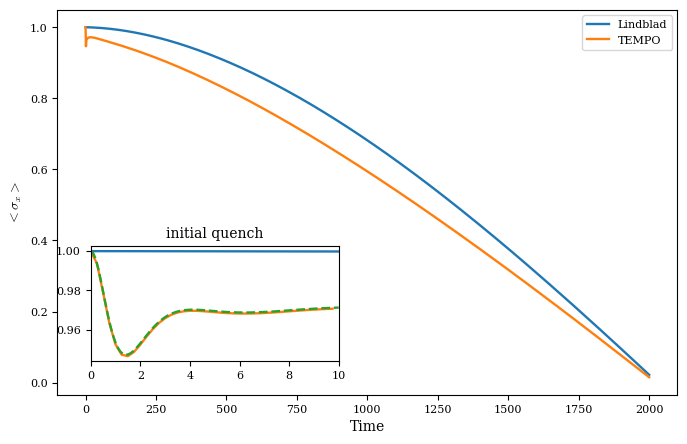

In [40]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
dt_fine=0.1
t_T_fine=np.linspace(0,10,int(10/dt_fine)+1)

assert len(dynamics_finer.states) == len(t_T_fine), "states and t_T_fine must have same length"

# main plot
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(t, [np.trace(state @ op.sigma("x")) for state in states[:-1]], label="Lindblad")
ax.plot(t_T, [np.trace(state @ op.sigma("x")) for state in dynamics.states], label="TEMPO")
ax.set_xlabel("Time")
ax.set_ylabel(r"$<\sigma_x>$")
ax.legend()
dt=5
t_inset=10
print(t[:int(t_inset/5)])

#inset
ax_inset = inset_axes(ax, width="40%", height="30%", loc='lower left',borderpad=3)  # adjust size/position
ax_inset.plot(t[:int(t_inset/dt_L)+1], [np.trace(state @ op.sigma("x")) for state in states[:int(t_inset/dt)+1]], label="Lindblad")
ax_inset.plot(t_T[:int(t_inset/dt_tempo)], [np.trace(state @ op.sigma("x")) for state in dynamics.states[:int(t_inset/dt_tempo)]], label="TEMPO")
ax_inset.plot(t_T_fine, [np.trace(state @ op.sigma("x")) for state in dynamics_finer.states], label="TEMPO finer", linestyle='dashed')
ax_inset.set_xlim(0, t_inset)
ax_inset.set_title("initial quench", fontsize=10)
ax_inset.tick_params(axis='both', which='major', labelsize=8)

plt.show()

In [41]:
def entropy_and_rates(state_list, dt,h_func):

    tempo_Ds=[]
    for i, state in enumerate(state_list):
        hx_t=h_func(i*dt)
        H = 2 * hx_t * sx
        T=0.131

        beta = 1 / T
        tau = expm(-beta * H)
        tau /= np.trace(tau)
        D_rt = np.real(
            np.trace(state @ (logm(state) - logm(tau)))
        )

        tempo_Ds.append(D_rt)

    tempo_Ds=np.array(tempo_Ds)
    tempo_Ddots = np.gradient(tempo_Ds, dt)

    return tempo_Ds, tempo_Ddots

In [42]:
tempo_Ds,tempo_Ddots=entropy_and_rates(dynamics.states,dt_tempo,h_t)


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


In [43]:
tempo_Ds_fine,tempo_Ddots_fine=entropy_and_rates(dynamics_finer.states,dt_fine,h_t)

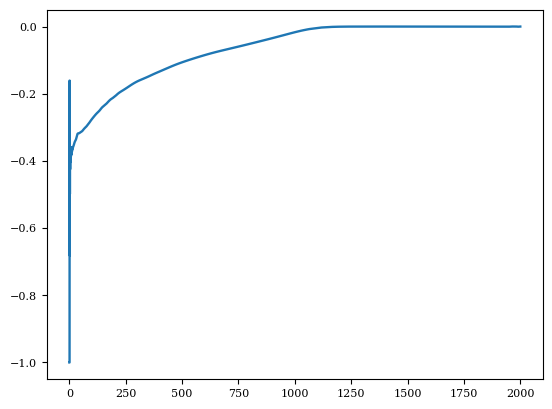

In [44]:
opt_control_tempo=np.ones(len(opt_prot["result"].x[0::3])+1)*opt_prot["result"].x[0::3][-1]
opt_control_tempo[:-1]=opt_prot["result"].x[0::3]

test_func=lambda t: opt_control_tempo[int(t/dt_tempo_opt)]
test_list=[test_func(ti) for ti in t_T]
plt.plot(t_T,test_list)

t_total=2000
dt_tempo=0.1
t_T_opt = np.arange(int(t_total/dt_tempo)+1) * dt_tempo

h_t_optx = interp1d(
    t_T_opt,
    opt_control_tempo,
    kind="cubic",     
    bounds_error=False,
    fill_value=(opt_control_tempo[0], opt_control_tempo[-2])
)

In [45]:
opt_tempo_Ds,opt_tempo_Ddots=entropy_and_rates(optimal_states,dt_tempo_opt,h_t_optx )

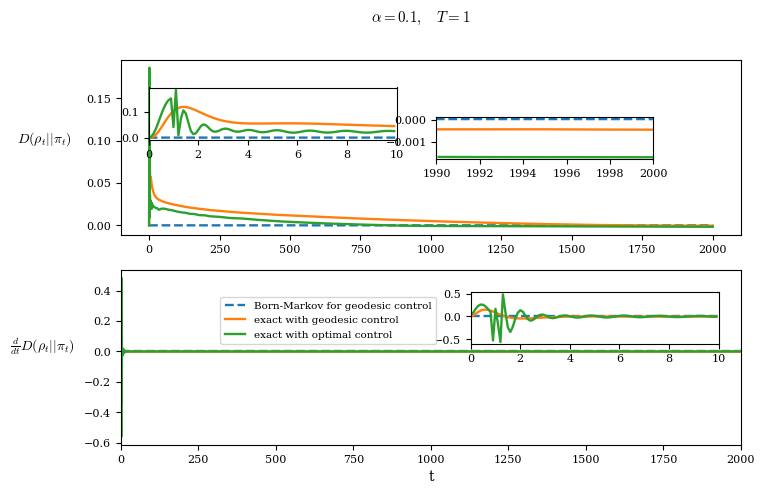

In [46]:
fig, ax = plt.subplots(2,figsize=(8,5))
t_total=2000
t_opt=np.linspace(0,2000,len(optimal_states))
t=np.linspace(0,t_total,int(t_total//5))
t_inset=10
ax[0].plot(t, D,linestyle='dashed',label="Born-Markov for geodesic control")
ax[0].plot(t_T, tempo_Ds, label="exact with geodesic control")
ax[0].plot(t_opt,opt_tempo_Ds,label="exact with optimal control")


ax_inset1 = inset_axes(ax[0], width="40%", height="30%", loc='upper left',borderpad=2.5)  # adjust size/position

ax_inset1.plot(t[:int(t_inset/dt)+1], D[:int(t_inset/dt)+1], linestyle='dashed', label="Born-Markov for geodesic control")
ax_inset.plot(t_T[:int(t_inset/dt_tempo)], tempo_Ds[:int(t_inset/dt_tempo)], label="TEMPO")
ax_inset1.plot(t_T_fine[:-1], tempo_Ds_fine[:int(t_inset/dt_fine)], label="exact for geodesic control")
ax_inset1.plot(t_opt[:int(t_inset/dt_tempo_opt)], opt_tempo_Ds[:int(t_inset/dt_tempo_opt)], label="exact with optimal control")

ax_inset1.set_xlim(0, t_inset)
ax_inset1.tick_params(axis='both', which='major', labelsize=8)

ax_inset3= inset_axes(ax[0], width="50%", height="40%", bbox_to_anchor=(.5, .4, .7, .6),
                   bbox_transform=ax[0].transAxes, loc="lower left")  # adjust size/position


ax_inset3.plot(t_T[-int(t_inset/dt_tempo):], tempo_Ds[-int(t_inset/dt_tempo):],color='C1', label="TEMPO")

ax_inset3.plot(t_opt[-int(t_inset/dt_tempo_opt):], opt_tempo_Ds[-int(t_inset/dt_tempo_opt):], color='C2',label="exact with optimal control")
ax_inset3.plot(t[-(int(t_inset/dt)+1):], D[-(int(t_inset/dt)+1):], color='C0', linestyle='dashed', label="Born-Markov for geodesic control")
ax_inset3.set_xlim(2000-t_inset,2000)
#ax_inset3.set_title("final quench", fontsize=10)
ax_inset3.tick_params(axis='both', which='major', labelsize=8)

ax[0].set_ylabel(r"$D(\rho_t || \pi_t)$", rotation=0,labelpad=30)
#ax[0].set_xlabel(r"$t$")
#plt.legend()

ax[1].plot(t, Ddot, linestyle='dashed',label="Born-Markov for geodesic control")
ax[1].plot(t_T, tempo_Ddots,label="exact with geodesic control")
ax[1].plot(t_opt,opt_tempo_Ddots,label="exact with optimal control")
ax[1].set_ylabel(r"$\frac{d}{dt}D(\rho_t || \pi_t)$",rotation=0,labelpad=30)
ax[1].set_xlabel("t")
#ax.set_xscale("log")
ax[1].set_xlim(0,2000)
ax_inset2 = inset_axes(ax[1], width="40%", height="30%", loc='upper right',borderpad=2)  # adjust size/position

ax_inset2.plot(t[:int(t_inset/dt)+1], Ddot[:int(t_inset/dt)+1], linestyle='dashed',label="Born-Markov for geodesic control")
#ax_inset.plot(t_T[:int(t_inset/dt_tempo)], tempo_Ddots[:int(t_inset/dt_tempo)], label="TEMPO")
ax_inset2.plot(t_T_fine[:-1], tempo_Ddots_fine[:int(t_inset/dt_fine)], label="exact with geodesic control")
ax_inset2.plot(t_opt[:int(t_inset/dt_tempo_opt)], opt_tempo_Ddots[:int(t_inset/dt_tempo_opt)], label="exact with optimal control")

ax_inset2.set_xlim(0, t_inset)
ax_inset2.tick_params(axis='both', which='major', labelsize=8)

fig.suptitle(r"$\alpha=0.1, \quad T=1$")
plt.legend(loc='best', bbox_to_anchor=(-0.12, 1),fontsize='small')
plt.show()

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_903/512967618.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


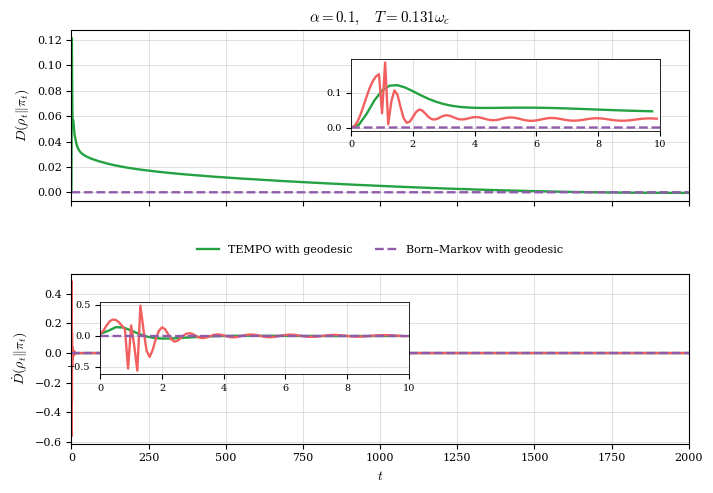

In [47]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# --------------------------------------------------
# STYLE (copied from reference figure)
# --------------------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.7,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

colors = {
    "tempo": "#24a141",
    "opt": "#f25f5f",
    "bm": "#915bac"
}

# --------------------------------------------------
# helper styling
# --------------------------------------------------
def style_axis(a):
    a.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    a.set_axisbelow(True)

def style_inset(a):
    for spine in a.spines.values():
        spine.set_linewidth(0.6)
    a.tick_params(labelsize=7)
    a.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    a.set_axisbelow(True)

# --------------------------------------------------
# TIME ARRAYS (UNCHANGED)
# --------------------------------------------------
t_total = 2000
dt = 5
dt_tempo_opt = 0.1
dt_tempo = 0.25
t_inset = 10

t_L = np.arange(len(hx)) * dt_L

# TEMPO simulation times
t_T = np.arange(int(t_total/dt_tempo)+1) * dt_tempo

t = np.linspace(0, t_total, int(t_total//5))
t_opt = np.linspace(0, 2000, len(optimal_states))

# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig, ax = plt.subplots(2, figsize=(7.2,5), sharex=True)

# ==================================================
# PANEL (a)
# ==================================================
ax[0].plot(t_T, tempo_Ds, color=colors["tempo"], label="TEMPO with geodesic")
#ax[0].plot(t_opt, opt_tempo_Ds, color=colors["opt"], label="TEMPO with optimal")
ax[0].plot(t, D, linestyle="--", color=colors["bm"],
           label="Born–Markov with geodesic")

ax[0].set_ylabel(r"$D(\rho_t \Vert \pi_t)$")
style_axis(ax[0])

# ----- Insets (a) -----
ax_inset1 = inset_axes(ax[0], width="50%", height="42%",
                       loc='upper right', borderpad=2.6)

ax_inset1.plot(t_T[:int(t_inset/dt_tempo)],
               tempo_Ds[:int(t_inset/dt_tempo)],
               color=colors["tempo"])
ax_inset1.plot(t_opt[:int(t_inset/dt_tempo_opt)],
               opt_tempo_Ds[:int(t_inset/dt_tempo_opt)],
               color=colors["opt"])
ax_inset1.plot(t[:int(t_inset/dt)+1],
               D[:int(t_inset/dt)+1],
               linestyle="--", color=colors["bm"])

ax_inset1.set_xlim(0, t_inset)
style_inset(ax_inset1)
"""
ax_inset3 = inset_axes(ax[0], width="40%", height="32%",
                       loc='upper right', borderpad=1)

ax_inset3.plot(t_T[-int(t_inset/dt_tempo):],
               tempo_Ds[-int(t_inset/dt_tempo):],
               color=colors["tempo"])
ax_inset3.plot(t_opt[-int(t_inset/dt_tempo_opt):],
               opt_tempo_Ds[-int(t_inset/dt_tempo_opt):],
               color=colors["opt"])
ax_inset3.plot(t[-(int(t_inset/dt)+1):],
               D[-(int(t_inset/dt)+1):],
               linestyle="--", color=colors["bm"])

ax_inset3.set_xlim(t_total - t_inset, t_total)
style_inset(ax_inset3)
"""
# ==================================================
# PANEL (b)
# ==================================================
ax[1].plot(t_T, tempo_Ddots, color=colors["tempo"])
ax[1].plot(t_opt, opt_tempo_Ddots, color=colors["opt"])
ax[1].plot(t, Ddot, linestyle="--", color=colors["bm"])

ax[1].set_ylabel(r"$\dot{D}(\rho_t \Vert \pi_t)$")
ax[1].set_xlabel(r"$t$")
ax[1].set_xlim(0, t_total)


style_axis(ax[1])

# ----- Insets (b) -----
ax_inset2 = inset_axes(ax[1], width="50%", height="42%",
                       loc='upper left', borderpad=2.6)

ax_inset2.plot(t_T[:int(t_inset/dt_tempo)],
               tempo_Ddots[:int(t_inset/dt_tempo)],
               color=colors["tempo"])
ax_inset2.plot(t_opt[:int(t_inset/dt_tempo_opt)],
               opt_tempo_Ddots[:int(t_inset/dt_tempo_opt)],
               color=colors["opt"])
ax_inset2.plot(t[:int(t_inset/dt)+1],
               Ddot[:int(t_inset/dt)+1],
               linestyle="--", color=colors["bm"])

ax_inset2.set_xlim(0, t_inset)
style_inset(ax_inset2)
"""
ax_inset4 = inset_axes(ax[1], width="40%", height="32%",
                       loc='upper right', borderpad=1)

ax_inset4.plot(t_T[-int(t_inset/dt_tempo):],
               tempo_Ddots[-int(t_inset/dt_tempo):],
               color=colors["tempo"])
ax_inset4.plot(t_opt[-int(t_inset/dt_tempo_opt):],
               opt_tempo_Ddots[-int(t_inset/dt_tempo_opt):],
               color=colors["opt"])
ax_inset4.plot(t[-(int(t_inset/dt)+1):],
               Ddot[-(int(t_inset/dt)+1):],
               linestyle="--", color=colors["bm"])

ax_inset4.set_xlim(t_total - t_inset, t_total)
style_inset(ax_inset4)
"""
# --------------------------------------------------
# TITLE + LEGEND
# --------------------------------------------------
ax[0].set_title(r"$\alpha=0.1, \quad T=0.131 \omega_c$")
ax[0].legend(frameon=False,
             loc="upper center",
             bbox_to_anchor=(0.5, -0.2),
             ncol=3)

plt.tight_layout()
plt.savefig('paper_figs/entropy_highercoup.pdf', format='pdf')
plt.show()

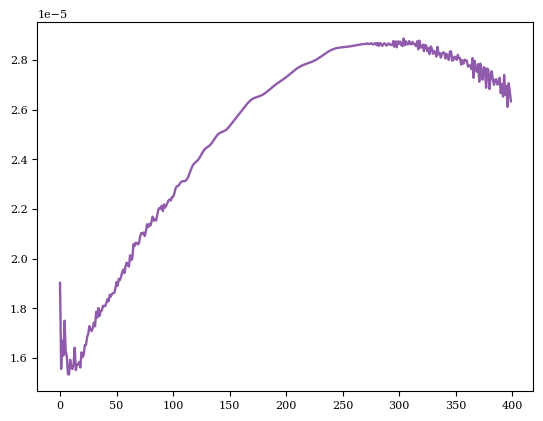

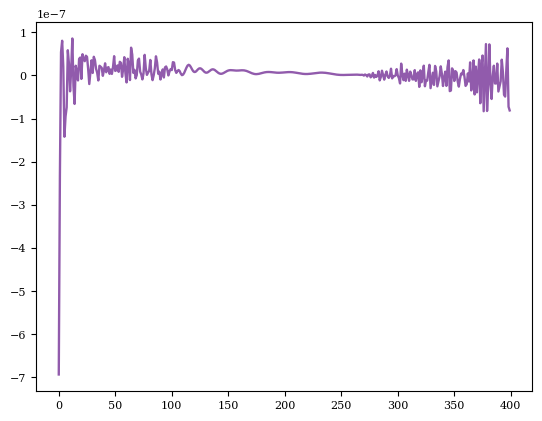

In [48]:

plt.plot(D,  color=colors["bm"],
           label="Born–Markov with geodesic")
plt.show()
plt.plot(Ddot,  color=colors["bm"],
           label="Born–Markov with geodesic")
plt.show()

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


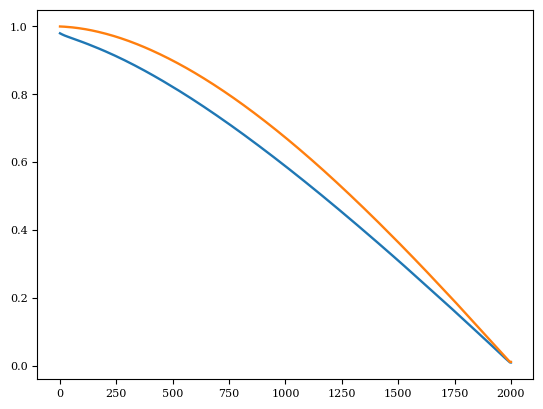

In [49]:
tebd_steadystates=[]
gibbs_states=[]

t_ss=np.linspace(0,2000,len(optimal_states))
for t in t_ss:
    h_s=op.sigma("x")*h_t(t)
    ss_tebd=oqupy.iTEBD_TEMPO_useoqupybath.iTEBD_TEMPO_oqupy.steadystate(
        self=process_tensor._tebd,
        h_s=h_s)
    
    T = 0.131
    beta = 1/T

    tau = expm(-beta * h_s)
    tau /= np.trace(tau)

    tebd_steadystates.append(ss_tebd)
    gibbs_states.append(tau)

plt.plot(t_ss,[np.trace(state @ op.sigma("x")) for state in tebd_steadystates])
plt.plot(t_ss,[np.trace(state @ op.sigma("x")) for state in gibbs_states])


In [50]:
def entropy_and_rates_meanforce(state_list,ss_list,dt):

    tempo_Ds=[]

    for i, state in enumerate(state_list):
        hx_t = h_t(i*dt)
        H = 2 * hx_t * sx

        log_rho = log_density_matrix(state)
        log_tau = log_density_matrix(ss_list[i])

        D_rt = np.real(np.trace(state @ (log_rho - log_tau)))
        tempo_Ds.append(D_rt)

    tempo_Ds = np.array(tempo_Ds)
    """
    tempo_Ddots = savgol_filter(
        tempo_Ds,
        window_length=40,
        polyorder=3,
        deriv=1,
        delta=dt
    )
    """

    t = np.arange(len(tempo_Ds)) * dt

    # smoothing parameter s controls smoothness
    #spline = UnivariateSpline(t, tempo_Ds, s=1e-3)

    #tempo_Ddots = spline.derivative()(t)

    tempo_Ddots = np.gradient(tempo_Ds, dt)

    return tempo_Ds, tempo_Ddots

In [51]:

#tempo_meanforce_D,tempo_meanforce_Ddots=entropy_and_rates_meanforce(optimal_states,tebd_steadystates,dt_fine)

plt.plot(t_ss,tempo_meanforce_D)
plt.plot(t_opt,opt_tempo_Ds,linestyle='dashed')
plt.show()
plt.plot(t_ss,tempo_meanforce_Ddots)
plt.plot(t_opt,opt_tempo_Ddots,linestyle='dashed')
plt.xlim(10,2000)
plt.show()
plt.plot(t_ss,tempo_meanforce_Ddots)
plt.plot(t_opt,opt_tempo_Ddots,linestyle='dashed')
plt.xlim(0,10)
plt.show()
plt.plot(t_ss,tempo_meanforce_Ddots)
plt.plot(t_opt,opt_tempo_Ddots,linestyle='dashed')
plt.xlim(3990,4000)
plt.show()

NameError: name 'tempo_meanforce_D' is not defined

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)


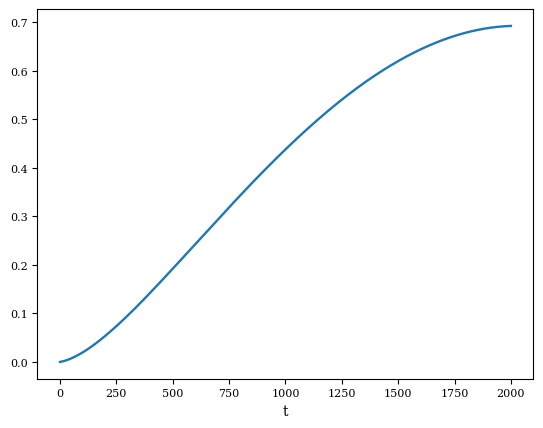

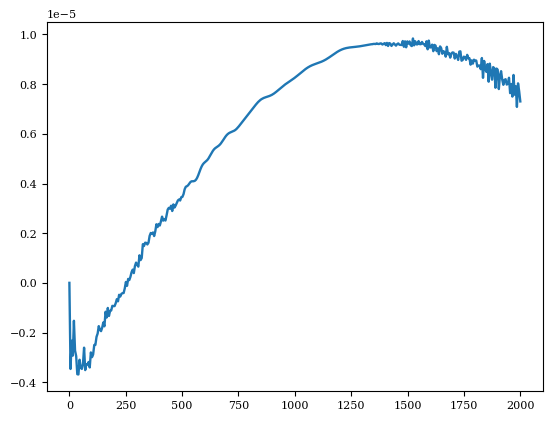

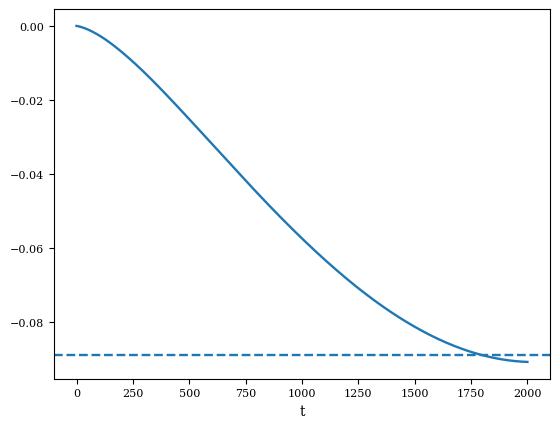

In [ ]:
def entropy(rho):
    return -np.real(np.trace(rho @ logm(rho)))

t=np.linspace(0,2000,len(states)-1)
delta_Ss=[entropy(state) - entropy(op.spin_dm("x+")) for state in states]
plt.plot(t, delta_Ss[:-1])
plt.xlabel("t")
plt.show()
plt.plot(t,D-D[0])
plt.show()
delta_Ds=D-D[0]
int_delta_Ddots=np.cumsum(Ddot)*dt
plt.plot(t,-0.131*(np.array(delta_Ss)[:-1]-np.array(delta_Ds)))
plt.axhline(results_lindblad_temp[(5.0)]["heats"][-1],linestyle='dashed')
plt.xlabel("t")
plt.show()

In [ ]:
# now get results for lower coupling, higher temperature
results_lindblad2={}
alpha=0.05
temp=0.131*10

num_steps=int(4000/0.5) # lower coupling
h_max=20

with open(f'results/lindblad_control/a=0.05,T=10/dt=0.5/4000ps', 'rb') as f:
    opt_prot = dill.load(f)

results_lindblad2[(0.5)] = opt_prot

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


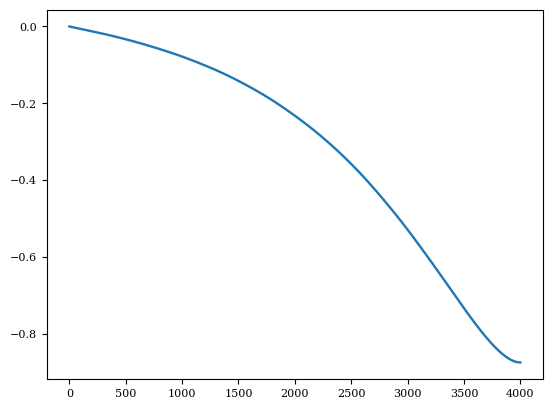

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_1617/207341753.py:15: RuntimeWarning: invalid value encountered in log
  return 2*np.log(np.sqrt(2)/np.tan(A+B*t/tau_prot))


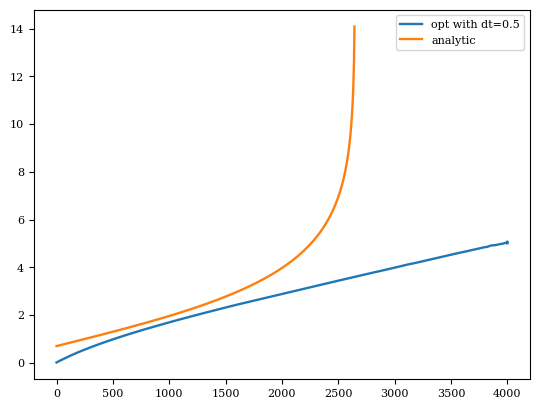

In [ ]:
t_total=4000 # lower coupling
t_lind=np.linspace(0,t_total,int(t_total/0.5)+1)

for key in results_lindblad2:
    plt.plot(np.linspace(0,t_total,int(t_total/key)+1), results_lindblad2[key]['heats'], label=f"dt={key}")
plt.show()

for key in results_lindblad2:
    hx=results_lindblad2[key]['x_opt']
    delta=-2*hx/(0.131*10)
    delta_reversed=delta[::-1]
    plt.plot(np.linspace(0,t_total,int(t_total/key)), delta_reversed, label=f"opt with dt={key}")

def min_dissip(A,B,t,tau_prot):
    return 2*np.log(np.sqrt(2)/np.tan(A+B*t/tau_prot))

t=np.linspace(0,t_total,int(t_total//5))
A=np.pi/4
EA=hx[-1]-hx[0]
B=-np.arcsin(np.tanh(EA/2))
plt.plot(t,min_dissip(A,B,t,t_total),label='analytic')
plt.legend()
plt.show()

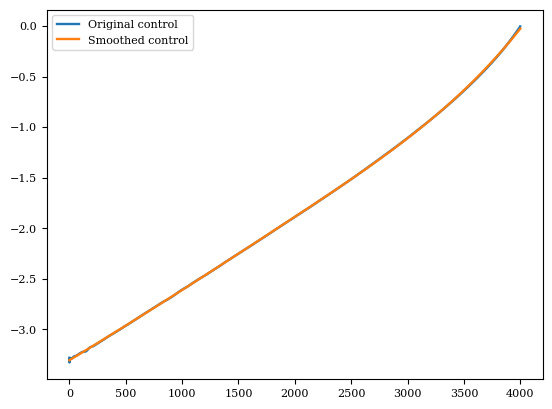

In [ ]:
from scipy.interpolate import UnivariateSpline

t_L=t_lind[:-1]  # control times (exclude final time)
# smoothing spline
# s controls smoothness (increase for smoother control)
spline = UnivariateSpline(t_L, hx, s=1e-1)

# smoothed control function
h_t = spline

# TEMPO times
t_T = np.arange(int(t_total/dt_tempo)+1) * dt_tempo

plt.step(t_L, hx, where="post", label="Original control")
plt.plot(t_T, h_t(t_T), label="Smoothed control")
plt.legend()
plt.show()

In [ ]:
opt_lind_control_smooth=[h_t(t) for t in np.linspace(0,4000,int(4000/0.5))]

In [ ]:

with open(f'results/lindblad_control/a={0.05},T={10}/dt=0.5/{4000:.0f}ps', 'rb') as f:
    lind_opts = dill.load(f)

heat_lind=lind_opts["heats"]
opt_lind_control=lind_opts["result"].x



In [ ]:
states2, D2, Ddot2, taus2= relative_entropy_from_optimal_control(
    opt_lind_control_smooth,
    int(4000/0.5),
    0.05,
    0.131*10,
    0.5
)

In [ ]:
with open(f'results/processtensors_lowercoupling_10K/processtensor_a=0.05_T=10_dt=0.1_ps=-8.0_tcut=500', 'rb') as f:
    process_tensor=dill.load(f)

sys= TimeDependentSystem(lambda t : op.sigma("x")*h_t(t))

dynamics2 = oqupy.compute_dynamics(
    process_tensor=process_tensor, 
    system=sys,
    initial_state=rho0,
    start_time=0,
    num_steps=int(t_total/dt_tempo))

--> Compute dynamics:
100.0% 16000 of 16000 [########################################] 00:10:13
Elapsed time: 613.0s


In [ ]:
from scipy.signal import savgol_filter
def entropy_and_rates(state_list, dt):

    tempo_Ds=[]
    for i, state in enumerate(state_list):
        hx_t=h_t(i*dt)
        H = 2*hx_t * sx
        T=0.131*10

        beta = 1 / T
        tau = expm(-beta * H) # negative hamiltonian hence flipped sign
        tau /= np.trace(tau)
        D_rt = np.real(
            np.trace(state @ (logm(state) - logm(tau)))
        )

        tempo_Ds.append(D_rt)

    tempo_Ds=np.array(tempo_Ds)
    tempo_Ddots = np.gradient(tempo_Ds, dt)
    """
    # window_length must be odd
    window = 60        # try 11–51 depending on data length
    polyorder = 3

    tempo_Ddots = savgol_filter(
    tempo_Ds,
    window_length=window,
    polyorder=polyorder,
    deriv=1,
    delta=dt
    )
    """

    return tempo_Ds, tempo_Ddots

In [ ]:
from scipy.signal import savgol_filter

from scipy.interpolate import UnivariateSpline
import numpy as np



def log_density_matrix(rho):
    vals, vecs = np.linalg.eigh(rho)
    vals = np.clip(vals, 1e-12, None)
    return vecs @ np.diag(np.log(vals)) @ vecs.conj().T

def entropy_and_rates(state_list, dt):

    tempo_Ds=[]

    for i, state in enumerate(state_list):
        hx_t = h_t(i*dt)
        H = 2 * hx_t * sx

        T = 0.131*10
        beta = 1/T

        tau = expm(-beta * H)
        tau /= np.trace(tau)

        log_rho = log_density_matrix(state)
        log_tau = log_density_matrix(tau)

        D_rt = np.real(np.trace(state @ (log_rho - log_tau)))
        tempo_Ds.append(D_rt)

    tempo_Ds = np.array(tempo_Ds)
    """
    tempo_Ddots = savgol_filter(
        tempo_Ds,
        window_length=40,
        polyorder=3,
        deriv=1,
        delta=dt
    )
    """

    t = np.arange(len(tempo_Ds)) * dt

    # smoothing parameter s controls smoothness
    #spline = UnivariateSpline(t, tempo_Ds, s=1e-3)

    #tempo_Ddots = spline.derivative()(t)

    tempo_Ddots = np.gradient(tempo_Ds, dt)

    return tempo_Ds, tempo_Ddots

In [ ]:
tempo_Ds2,tempo_Ddots2=entropy_and_rates(dynamics2.states,dt_tempo)

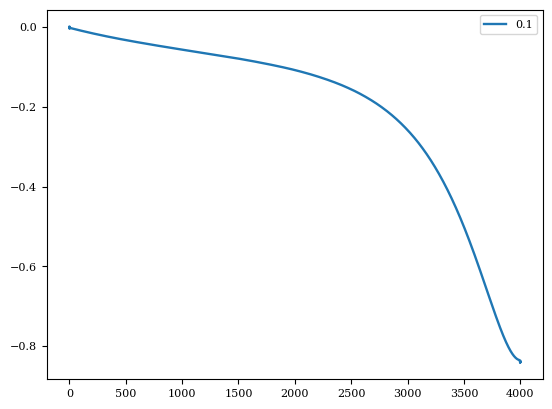

In [ ]:

for dt in [0.1]:
    with open(f'results/convergence_checks/a=0.05_T=10/dt={dt}_ps=-{8.0}_tcut=500_x=3.5/{4000}ps', 'rb') as f:
        conv_dict = dill.load(f)
        t_inset=4000
        plt.plot(np.linspace(4000-t_inset, 4000, int(t_inset/dt)), conv_dict["heats"][-int(t_inset/dt):], label={dt})
plt.legend()
plt.show()

In [ ]:
with open(f'results/zero_control_lowercoupling_10K/dt=0.1_ps=-8.0_tcut=500_x=3.5_y=0.0_z=0.0_headstart/4000ps', 'rb') as f:
    opt_prot2 = dill.load(f)

with open(f'results/zero_control_lowercoupling_10K/dt=0.25_ps=-6.0_tcut=500_x=3.5_y=0.0_z=0.0/4000ps', 'rb') as f:
    opt_prot3 = dill.load(f)

optimal_states_new=opt_prot["fidelitygrad"]["dynamics"].states
dt_tempo_opt=0.1



hx3=opt_prot3["result"].x[0::3]
plt.plot(np.linspace(0,4000,len(hx3)), hx3)

hx_new=opt_prot2["result"].x[0::3]
plt.plot(np.linspace(0,4000,len(hx_new)), hx_new)

plt.plot(np.linspace(0,4000,len(opt_lind_control)), opt_lind_control)




KeyError: 'fidelitygrad'

829


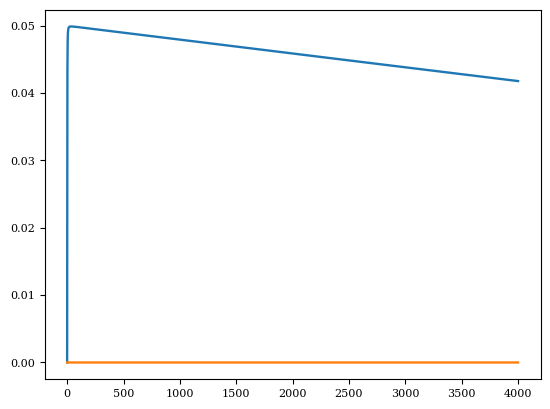

In [ ]:
num_its=np.shape(opt_prot3["log"])[0]
print(num_its)
heat3=opt_prot3["log"][0]["full heats"]
plt.plot(np.linspace(0,4000,len(heat3)), heat3)

heat_new=opt_prot2["log"][0]["full heats"]
plt.plot(np.linspace(0,4000,len(heat_new)), heat_new)

heat_lind=lind_opts["heats"]
#plt.plot(np.linspace(0,4000,len(heat_lind)), heat_lind)

In [ ]:
dynamics_opt2=conv_dict["dynamics"]
dt_tempo2=0.1
opt_tempo_Ds2,opt_tempo_Ddots2=entropy_and_rates(dynamics_opt2,dt_tempo2)

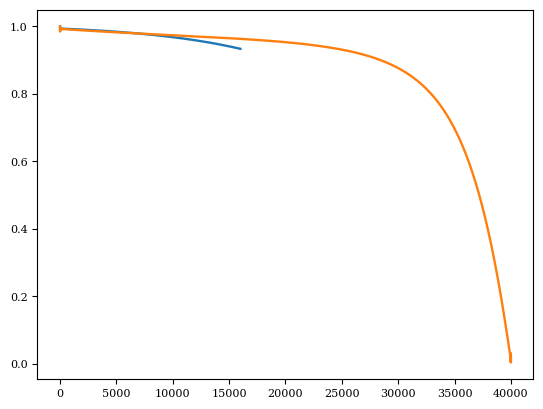

In [ ]:
plt.plot([np.trace(state @ op.sigma("x")) for state in dynamics2.states[:-1]],label="Lindblad")
plt.plot([np.trace(state @ op.sigma("x")) for state in dynamics_opt2[:-1]],label="Lindblad")

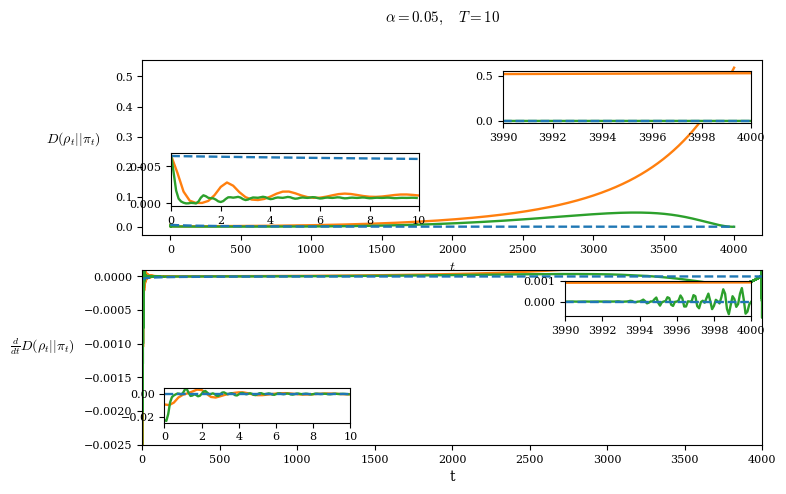

In [ ]:
fig, ax = plt.subplots(2,figsize=(8,5))

t_total=4000
dt=0.5
dt_tempo_opt=0.1
dt_tempo=0.1

t=np.linspace(0,t_total,int(t_total//0.5))
t_opt=np.linspace(0,4000,len(dynamics_opt2))
t_inset=10

ax[0].plot(t_T, tempo_Ds2,color='C1')
ax[0].plot(t_opt,opt_tempo_Ds2,color='C2')
ax[0].plot(t, D2,linestyle='dashed', color='C0')

ax_inset1 = inset_axes(ax[0], width="40%", height="30%", loc='lower left',borderpad=2.6)  # adjust size/position

ax_inset1.plot(t_T[:int(t_inset/dt_tempo)], tempo_Ds2[:int(t_inset/dt_tempo)], color='C1',label="TEMPO")
ax_inset1.plot(t_opt[:int(t_inset/dt_tempo_opt)], opt_tempo_Ds2[:int(t_inset/dt_tempo_opt)], color='C2',label="exact with optimal control")
ax_inset1.plot(t[:int(t_inset/dt)+1], D2[:int(t_inset/dt)+1], color='C0',linestyle='dashed', label="Born-Markov for geodesic control")
ax_inset1.set_xlim(0, t_inset)
#ax_inset1.set_title("initial quench", fontsize=10)
ax_inset1.tick_params(axis='both', which='major', labelsize=8)

ax_inset3= inset_axes(ax[0], width="40%", height="30%", loc='upper right',borderpad=1)  # adjust size/position


ax_inset3.plot(t_T[-int(t_inset/dt_tempo):], tempo_Ds2[-int(t_inset/dt_tempo):],color='C1', label="TEMPO")

ax_inset3.plot(t_opt[-int(t_inset/dt_tempo_opt):], opt_tempo_Ds2[-int(t_inset/dt_tempo_opt):], color='C2',label="exact with optimal control")
ax_inset3.plot(t[-(int(t_inset/dt)+1):], D2[-(int(t_inset/dt)+1):], color='C0', linestyle='dashed', label="Born-Markov for geodesic control")
ax_inset3.set_xlim(4000-t_inset,4000)
#ax_inset3.set_title("final quench", fontsize=10)
ax_inset3.tick_params(axis='both', which='major', labelsize=8)

ax[0].set_ylabel(r"$D(\rho_t || \pi_t)$", rotation=0,labelpad=30)
ax[0].set_xlabel(r"$t$")


ax[1].plot(t_T, tempo_Ddots2,color='C1',label="exact with geodesic control")
ax[1].plot(t_opt,opt_tempo_Ddots2,color='C2',label="exact with optimal control")
ax[1].plot(t, Ddot2, color='C0',linestyle='dashed',label="Born-Markov for geodesic control")
ax[1].set_ylabel(r"$\frac{d}{dt}D(\rho_t || \pi_t)$",rotation=0,labelpad=30)
ax[1].set_xlabel("t")
#ax.set_xscale("log")
ax[1].set_xlim(0,4000)

ax[1].set_ylim(-0.0025,0.0001)

ax_inset2 = inset_axes(ax[1], width="30%", height="20%", loc='lower left',borderpad=2)  # adjust size/position


ax_inset2.plot(t_T[:int(t_inset/dt_tempo)], tempo_Ddots2[:int(t_inset/dt_tempo)], color='C1', label="TEMPO")
ax_inset2.plot(t_opt[:int(t_inset/dt_tempo_opt)], opt_tempo_Ddots2[:int(t_inset/dt_tempo_opt)], color='C2', label="exact with optimal control")
ax_inset2.plot(t[:int(t_inset/dt)+1], Ddot2[:int(t_inset/dt)+1], color='C0',linestyle='dashed',label="Born-Markov for geodesic control")
ax_inset2.set_xlim(0, t_inset)
#ax_inset2.set_title("initial quench", fontsize=10)
ax_inset2.tick_params(axis='both', which='major', labelsize=8)

ax_inset4= inset_axes(ax[1], width="30%", height="20%", loc='upper right',borderpad=1)  # adjust size/position


ax_inset4.plot(t_T[-int(t_inset/dt_tempo):], tempo_Ddots2[-int(t_inset/dt_tempo):], color='C1',label="TEMPO")

ax_inset4.plot(t_opt[-int(t_inset/dt_tempo_opt):], opt_tempo_Ddots2[-int(t_inset/dt_tempo_opt):], color='C2',label="exact with optimal control")
ax_inset4.plot(t[-(int(t_inset/dt)+1):], Ddot2[-(int(t_inset/dt)+1):], color='C0', linestyle='dashed', label="Born-Markov for geodesic control")
ax_inset4.set_xlim(4000-t_inset,4000)
ax_inset4.tick_params(axis='both', which='major', labelsize=8)
#ax_inset3.set_title("final quench", fontsize=10)

fig.suptitle(r"$\alpha=0.05, \quad T=10$")
#plt.legend(loc='best', bbox_to_anchor=(-0.12, 1),fontsize='small')
plt.show()

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_1617/1106245222.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


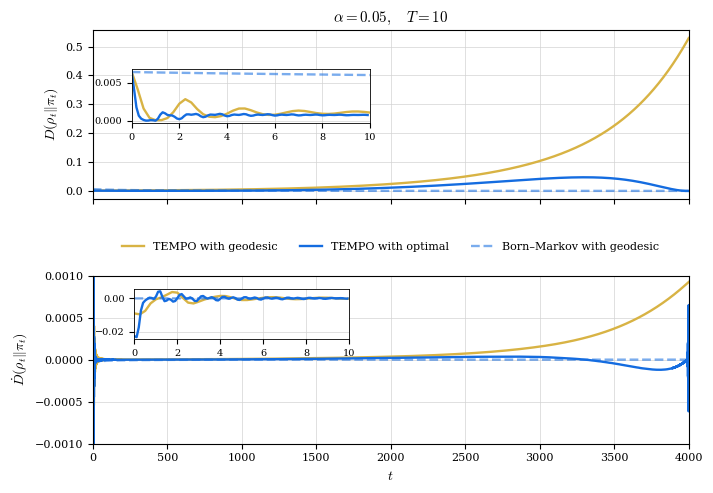

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

# --- Style parameters ---
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.7,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

# --- Colors ---
colors = {
    "tempo": "#d8b344",  # softer black
    "opt": "#146ce0",    # soft orange
    "bm": "#146ce0"+"90"      # pale grey for dashed BM lines
}
pale_colors = {
    "tempo": "#653b73"+"90",
    "opt": "#023cb0"+"90",
    "bm": "#146ce0"+"90"
}

fig, ax = plt.subplots(2, figsize=(7.2, 5), sharex=True)

t_total = 4000
dt = 0.5
dt_tempo_opt = 0.1
dt_tempo = 0.1
t_inset = 10
t_T=np.linspace(0, t_total, len(tempo_Ds2))
t_opt=np.linspace(0,t_total,len(opt_tempo_Ds2))
t=np.linspace(0,t_total,len(D2))

# --- Panel (a): Relative entropy ---
ax[0].plot(t_T, tempo_Ds2, color=colors["tempo"], label="TEMPO with geodesic")
ax[0].plot(t_opt, opt_tempo_Ds2, color=colors["opt"], label="TEMPO with optimal")
ax[0].plot(t, D2, linestyle="--", color=pale_colors["bm"], label="Born–Markov with geodesic")

ax[0].set_ylabel(r"$D(\rho_t \Vert \pi_t)$")
ax[0].grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax[0].set_axisbelow(True)

# --- Insets for panel (a) ---
def style_inset(a):
    for spine in a.spines.values():
        spine.set_linewidth(0.6)
    a.tick_params(labelsize=7)
    a.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    a.set_axisbelow(True)

ax_inset1 = inset_axes(ax[0], width="40%", height="32%", loc="upper left", borderpad=3.5)
ax_inset1.plot(t_T[:int(t_inset/dt_tempo)], tempo_Ds2[:int(t_inset/dt_tempo)], color=colors["tempo"])
ax_inset1.plot(t_opt[:int(t_inset/dt_tempo_opt)], opt_tempo_Ds2[:int(t_inset/dt_tempo_opt)], color=colors["opt"])
ax_inset1.plot(t[:int(t_inset/dt)+1], D2[:int(t_inset/dt)+1], linestyle="--", color=pale_colors["bm"])
ax_inset1.set_xlim(0, t_inset)
style_inset(ax_inset1)
"""
ax_inset3 = inset_axes(ax[0], width="40%", height="32%", loc="upper right", borderpad=1)
ax_inset3.plot(t_T[-int(t_inset/dt_tempo):], tempo_Ds2[-int(t_inset/dt_tempo):], color=colors["tempo"])
ax_inset3.plot(t_opt[-int(t_inset/dt_tempo_opt):], opt_tempo_Ds2[-int(t_inset/dt_tempo_opt):], color=colors["opt"])
ax_inset3.plot(t[-(int(t_inset/dt)+1):], D2[-(int(t_inset/dt)+1):], linestyle="--", color=pale_colors["bm"])
ax_inset3.set_xlim(t_total - t_inset, t_total)
style_inset(ax_inset3)
"""
# --- Panel (b): Entropy production rate ---
ax[1].plot(t_T, tempo_Ddots2, color=colors["tempo"])
ax[1].plot(t_opt, opt_tempo_Ddots2, color=colors["opt"])
ax[1].plot(t, Ddot2, linestyle="--", color=pale_colors["bm"])

ax[1].set_ylabel(r"$\dot{D}(\rho_t \Vert \pi_t)$")
ax[1].set_xlabel(r"$t$")
ax[1].set_xlim(0, t_total)
ax[1].set_ylim(-0.001, 0.001)
ax[1].grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
ax[1].set_axisbelow(True)

# Insets for panel (b)
inset_y = 0.62
inset_w = 0.36
inset_h = 0.3
left_x  = 0.07
right_x = 0.55

ax_inset2 = inset_axes(ax[1], width="100%", height="100%",
                       bbox_to_anchor=(left_x, inset_y, inset_w, inset_h),
                       bbox_transform=ax[1].transAxes, loc="lower left", borderpad=0)
ax_inset2.plot(t_T[:int(t_inset/dt_tempo)], tempo_Ddots2[:int(t_inset/dt_tempo)], color=colors["tempo"])
ax_inset2.plot(t_opt[:int(t_inset/dt_tempo_opt)], opt_tempo_Ddots2[:int(t_inset/dt_tempo_opt)], color=colors["opt"])
ax_inset2.plot(t[:int(t_inset/dt)+1], Ddot2[:int(t_inset/dt)+1], linestyle="--", color=pale_colors["bm"])
ax_inset2.set_xlim(0, t_inset)
style_inset(ax_inset2)
"""
ax_inset4 = inset_axes(ax[1], width="100%", height="100%",
                       bbox_to_anchor=(right_x, inset_y, inset_w, inset_h),
                       bbox_transform=ax[1].transAxes, loc="upper right", borderpad=0)
ax_inset4.plot(t_T[-int(t_inset/dt_tempo):], tempo_Ddots2[-int(t_inset/dt_tempo):], color=colors["tempo"])
ax_inset4.plot(t_opt[-int(t_inset/dt_tempo_opt):], opt_tempo_Ddots2[-int(t_inset/dt_tempo_opt):], color=colors["opt"])
ax_inset4.plot(t[-(int(t_inset/dt)+1):], Ddot2[-(int(t_inset/dt)+1):], linestyle="--", color=pale_colors["bm"])
ax_inset4.set_xlim(t_total - t_inset, t_total)
style_inset(ax_inset4)
"""
# --- Legend ---
ax[0].set_title(r"$\alpha=0.05, \quad T=10$")
ax[0].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)

plt.tight_layout()
plt.savefig('paper_figs/entropy_lowercoup.pdf', format='pdf')
plt.show()

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


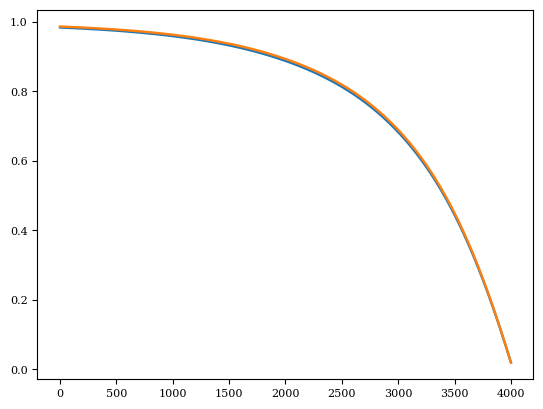

In [ ]:
tebd_steadystates=[]
gibbs_states=[]

t_ss=np.linspace(0,4000,len(dynamics_opt2))
for t in t_ss:
    h_s=op.sigma("x")*h_t(t)
    ss_tebd=oqupy.iTEBD_TEMPO_useoqupybath.iTEBD_TEMPO_oqupy.steadystate(
        self=process_tensor._tebd,
        h_s=h_s)
    
    T = 0.131*10
    beta = 1/T

    tau = expm(-beta * h_s)
    tau /= np.trace(tau)

    tebd_steadystates.append(ss_tebd)
    gibbs_states.append(tau)

plt.plot(t_ss,[np.trace(state @ op.sigma("x")) for state in tebd_steadystates])
plt.plot(t_ss,[np.trace(state @ op.sigma("x")) for state in gibbs_states])


In [ ]:
def entropy_and_rates_meanforce(state_list,ss_list,dt):

    tempo_Ds=[]

    for i, state in enumerate(state_list):
        hx_t = h_t(i*dt)
        H = 2 * hx_t * sx

        log_rho = log_density_matrix(state)
        log_tau = log_density_matrix(ss_list[i])

        D_rt = np.real(np.trace(state @ (log_rho - log_tau)))
        tempo_Ds.append(D_rt)

    tempo_Ds = np.array(tempo_Ds)
    """
    tempo_Ddots = savgol_filter(
        tempo_Ds,
        window_length=40,
        polyorder=3,
        deriv=1,
        delta=dt
    )
    """

    t = np.arange(len(tempo_Ds)) * dt

    # smoothing parameter s controls smoothness
    #spline = UnivariateSpline(t, tempo_Ds, s=1e-3)

    #tempo_Ddots = spline.derivative()(t)

    tempo_Ddots = np.gradient(tempo_Ds, dt)

    return tempo_Ds, tempo_Ddots

state_list_short=dynamics_opt2
print(len(state_list_short))
print(len(tebd_steadystates))
tempo_meanforce_D,tempo_meanforce_Ddots=entropy_and_rates_meanforce(state_list_short,tebd_steadystates,dt_tempo_opt*len(dynamics_opt2)/1000)

40001
40001


40001
40001


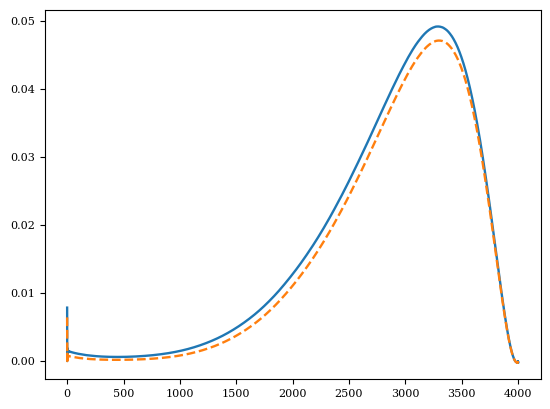

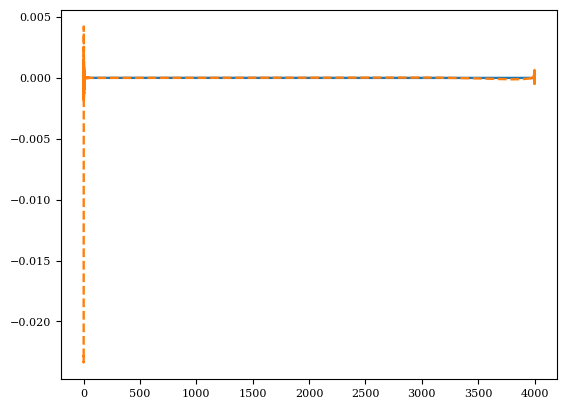

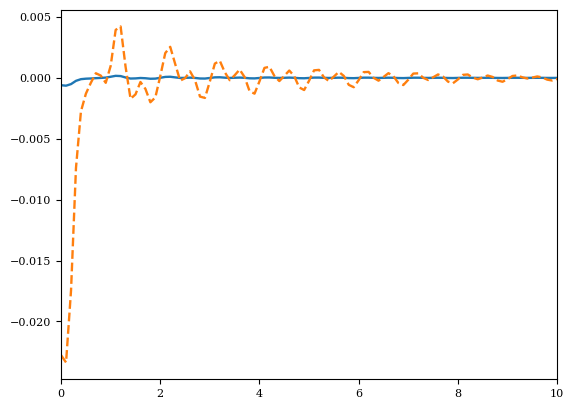

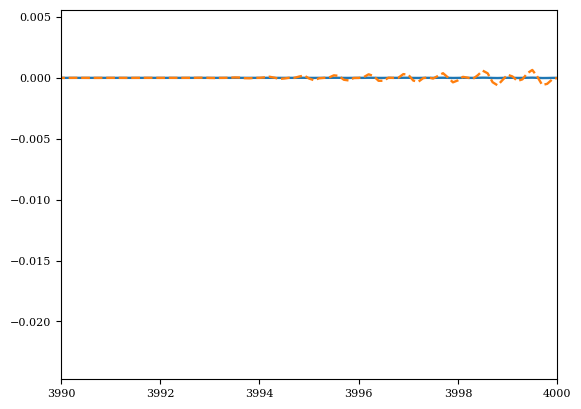

In [ ]:
tate_list_short=dynamics_opt2
print(len(state_list_short))
print(len(tebd_steadystates))
tempo_meanforce_D,tempo_meanforce_Ddots=entropy_and_rates_meanforce(state_list_short,tebd_steadystates,dt_tempo_opt*len(dynamics_opt2)/1000)

plt.plot(t_ss,tempo_meanforce_D)
plt.plot(t_opt,opt_tempo_Ds2,linestyle='dashed')
plt.show()
plt.plot(t_ss,tempo_meanforce_Ddots)
plt.plot(t_opt,opt_tempo_Ddots2,linestyle='dashed')
plt.show()
plt.plot(t_ss,tempo_meanforce_Ddots)
plt.plot(t_opt,opt_tempo_Ddots2,linestyle='dashed')
plt.xlim(0,10)
plt.show()
plt.plot(t_ss,tempo_meanforce_Ddots)
plt.plot(t_opt,opt_tempo_Ddots2,linestyle='dashed')
plt.xlim(3990,4000)
plt.show()

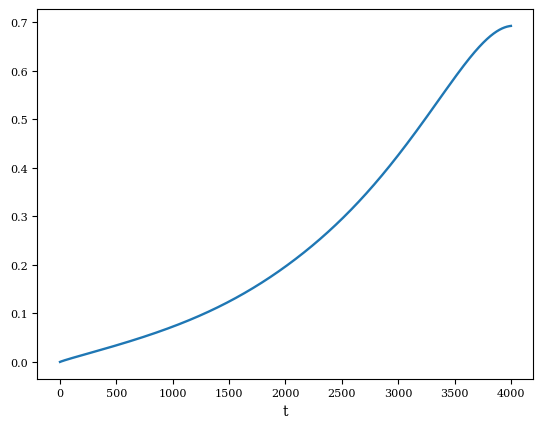

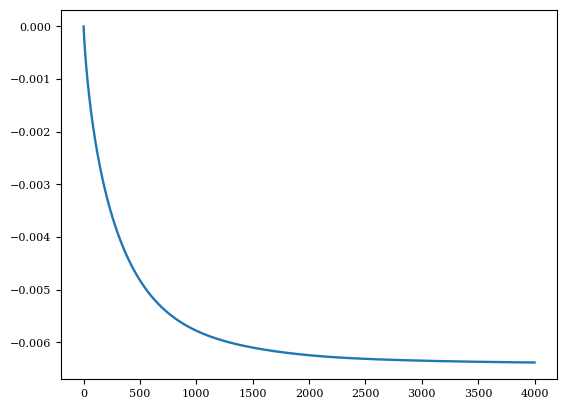

In [ ]:
def entropy(rho):
    return -np.real(np.trace(rho @ logm(rho)))
t=np.linspace(0,4000,len(states2))
delta_Ss=[entropy(state) - entropy(op.spin_dm("x+")) for state in states2]
plt.plot(t, delta_Ss)
plt.xlabel("t")
plt.show()
plt.plot(t[:-1],D2-D2[0])
plt.show()
delta_Ds=D2-D2[0]
int_delta_Ddots=np.cumsum(Ddot2)*dt

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


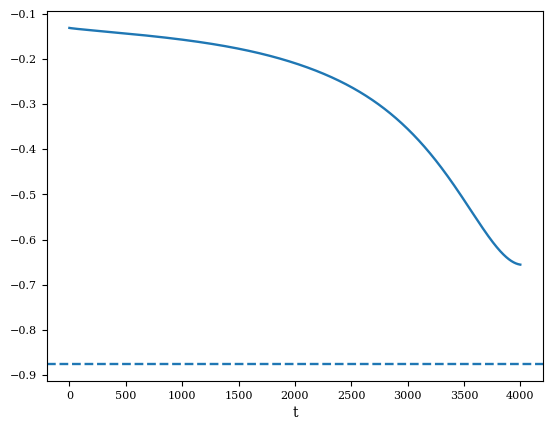

In [ ]:
plt.plot(t[:-1],-0.131*10**(np.array(delta_Ss)[:-1]-np.array(delta_Ds)))
plt.axhline(results_lindblad2[(0.5)]["heats"][-1],linestyle='dashed')
plt.xlabel("t")
plt.show()

In [ ]:
# plot entropy rate (top gibbs entropy), (bottom exact steady state entropy)